In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("rossmann_model_ready.csv",low_memory=False)

In [5]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoInterval,Year,Month,Day,Quarter,Season,CompetitionDuration,PromoDuration,DistanceGroup,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,No Promo,2015,7,31,3,Summer,82,0.0,1-5 km,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,7,31,3,Summer,92,64.0,0-1 km,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,7,31,3,Summer,103,51.0,10-20 km,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,No Promo,2015,7,31,3,Summer,70,0.0,0-1 km,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,No Promo,2015,7,31,3,Summer,3,0.0,>20 km,0


In [6]:
df.shape

(844392, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Store                844392 non-null  int64  
 1   DayOfWeek            844392 non-null  int64  
 2   Date                 844392 non-null  object 
 3   Sales                844392 non-null  int64  
 4   Customers            844392 non-null  int64  
 5   Open                 844392 non-null  int64  
 6   Promo                844392 non-null  int64  
 7   StateHoliday         844392 non-null  object 
 8   SchoolHoliday        844392 non-null  int64  
 9   StoreType            844392 non-null  object 
 10  Assortment           844392 non-null  object 
 11  CompetitionDistance  844392 non-null  float64
 12  Promo2               844392 non-null  int64  
 13  PromoInterval        844392 non-null  object 
 14  Year                 844392 non-null  int64  
 15  Month            

In [8]:
df.isnull().sum()

Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Customers              0
Open                   0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
PromoInterval          0
Year                   0
Month                  0
Day                    0
Quarter                0
Season                 0
CompetitionDuration    0
PromoDuration          0
DistanceGroup          0
IsPromoMonth           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'Promo2', 'PromoInterval', 'Year', 'Month',
       'Day', 'Quarter', 'Season', 'CompetitionDuration', 'PromoDuration',
       'DistanceGroup', 'IsPromoMonth'],
      dtype='object')

In [11]:
df = df.drop(
    columns=[
        "Date",
        "Open",
        "Customers",
        "PromoInterval",
        "DistanceGroup"
    ]
)

In [12]:
df.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Year',
       'Month', 'Day', 'Quarter', 'Season', 'CompetitionDuration',
       'PromoDuration', 'IsPromoMonth'],
      dtype='object')

In [13]:
df.select_dtypes(include="object").columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'Season'], dtype='object')

In [14]:
categorical_columns = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "Season"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [15]:
df.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Promo', 'SchoolHoliday',
       'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'Quarter',
       'CompetitionDuration', 'PromoDuration', 'IsPromoMonth',
       'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c',
       'Season_Spring', 'Season_Summer', 'Season_Winter'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Store                844392 non-null  int64  
 1   DayOfWeek            844392 non-null  int64  
 2   Sales                844392 non-null  int64  
 3   Promo                844392 non-null  int64  
 4   SchoolHoliday        844392 non-null  int64  
 5   CompetitionDistance  844392 non-null  float64
 6   Promo2               844392 non-null  int64  
 7   Year                 844392 non-null  int64  
 8   Month                844392 non-null  int64  
 9   Day                  844392 non-null  int64  
 10  Quarter              844392 non-null  int64  
 11  CompetitionDuration  844392 non-null  int64  
 12  PromoDuration        844392 non-null  float64
 13  IsPromoMonth         844392 non-null  int64  
 14  StateHoliday_a       844392 non-null  int64  
 15  StateHoliday_b   

In [17]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(675513, 24)
(168879, 24)
(675513,)
(168879,)


## Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lr=LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_train_pred = lr.predict(X_train)

In [23]:
y_test_pred = lr.predict(X_test)

In [24]:
print("Training Performance")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", mean_squared_error(y_train, y_train_pred) ** 0.5)
print("R2 :", r2_score(y_train, y_train_pred))

Training Performance
MAE : 1998.5351738145491
RMSE: 2730.6556638794714
R2 : 0.22604299676716832


In [25]:
print("Testing Performance")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", mean_squared_error(y_test, y_test_pred) ** 0.5)
print("R2 :", r2_score(y_test, y_test_pred))

Testing Performance
MAE : 1998.8438689650357
RMSE: 2730.583768449711
R2 : 0.22684869318543677


### Linear Regression Results

- Linear Regression was used as the baseline regression model.
- The model achieved an R² score of approximately **22.7%** on both the training and testing datasets.
- Training and testing metrics are almost identical, indicating that the model is **not overfitting**.
- However, the relatively low R² score suggests that the model is **underfitting** and is unable to capture the complex, non-linear relationships present in the data.
- Therefore, more powerful tree-based ensemble models such as Decision Tree, Random Forest, and XGBoost will be evaluated in the next stage.

## Decision Tree Regressor

In [26]:
from sklearn.tree import DecisionTreeRegressor

In [27]:
dt = DecisionTreeRegressor(random_state=42)

In [28]:
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [29]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [30]:
print("Training Performance")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", mean_squared_error(y_train, y_train_pred) ** 0.5)
print("R2 :", r2_score(y_train, y_train_pred))

print()

print("Testing Performance")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", mean_squared_error(y_test, y_test_pred) ** 0.5)
print("R2 :", r2_score(y_test, y_test_pred))

Training Performance
MAE : 0.0
RMSE: 0.0
R2 : 1.0

Testing Performance
MAE : 817.7280242066805
RMSE: 1315.701181521142
R2 : 0.8204985277021809


### Decision Tree Results

- The Decision Tree Regressor achieved **perfect performance** on the training dataset with an R² score of **1.00**, indicating that it completely memorized the training data.
- On the testing dataset, the model achieved an **R² score of 0.8205**, which is significantly higher than the Linear Regression model.
- Despite the improved testing performance, the large gap between training and testing metrics indicates that the model is **overfitting**.
- Decision Trees are highly flexible and can capture complex non-linear relationships, but without regularization they tend to memorize the training data.
- To improve generalization and reduce overfitting, ensemble methods such as **Random Forest** will be evaluated next.

## Random Forest Regressor

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [33]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

In [35]:
print("Training Performance")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", mean_squared_error(y_train, y_train_pred) ** 0.5)
print("R2 :", r2_score(y_train, y_train_pred))

print()

print("Testing Performance")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", mean_squared_error(y_test, y_test_pred) ** 0.5)
print("R2 :", r2_score(y_test, y_test_pred))

Training Performance
MAE : 224.24902376416145
RMSE: 357.3278500914744
R2 : 0.986746923978605

Testing Performance
MAE : 602.6160158456646
RMSE: 954.9204722845269
R2 : 0.9054442608236538


### Random Forest Results

- The Random Forest Regressor achieved an R² score of **0.9867** on the training dataset and **0.9054** on the testing dataset.
- Compared to the Decision Tree model, Random Forest significantly improved the testing performance while reducing overfitting.
- The model achieved a low testing MAE of **602.62** and RMSE of **954.92**, indicating more accurate predictions.
- By combining multiple decision trees, Random Forest provides better generalization and more robust predictions than a single Decision Tree.
- Among the models evaluated so far, Random Forest demonstrates the best balance between training performance and testing performance.

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,CompetitionDistance,0.248422
0,Store,0.216124
2,Promo,0.135761
10,CompetitionDuration,0.085405
1,DayOfWeek,0.066078
8,Day,0.050740
7,Month,0.032763
11,PromoDuration,0.029212
16,StoreType_b,0.025856
20,Assortment_c,0.023172


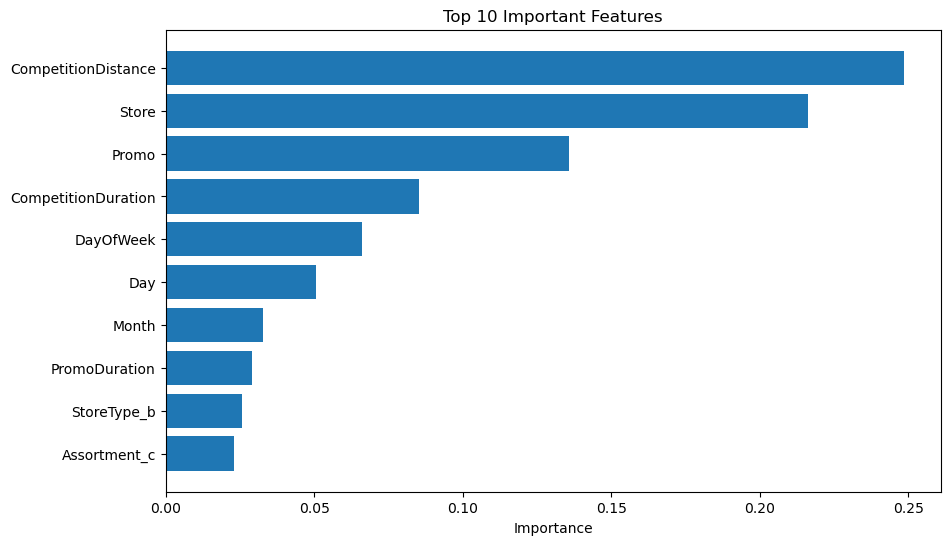

In [37]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [38]:
rf.feature_importances_

array([2.16123959e-01, 6.60781625e-02, 1.35761040e-01, 5.33323914e-03,
       2.48421598e-01, 2.12134666e-02, 7.80313088e-03, 3.27628180e-02,
       5.07400993e-02, 3.64675588e-03, 8.54049140e-02, 2.92116683e-02,
       2.44685149e-03, 1.07534959e-03, 4.06161595e-04, 1.04511503e-04,
       2.58562094e-02, 1.94110455e-02, 1.74528505e-02, 8.22105020e-04,
       2.31716727e-02, 2.80862503e-03, 2.71438335e-03, 1.22938252e-03])

In [39]:
df['Sales'].describe()

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

## XG Boost Regressor

In [40]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [42]:
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

In [43]:
print("Training Performance")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2 :", r2_score(y_train, y_train_pred))

print("\nTesting Performance")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2 :", r2_score(y_test, y_test_pred))

Training Performance
MAE : 499.80987548828125
RMSE: 711.5079716700299
R2 : 0.9474536776542664

Testing Performance
MAE : 546.1409301757812
RMSE: 793.8101158337553
R2 : 0.9346588850021362


In [44]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

StoreType_b            0.322188
Promo                  0.109489
Promo2                 0.105449
Assortment_c           0.073586
CompetitionDistance    0.067622
StoreType_c            0.062598
Store                  0.053338
Assortment_b           0.045631
StoreType_d            0.042651
CompetitionDuration    0.020495
PromoDuration          0.015856
DayOfWeek              0.015598
Month                  0.010678
StateHoliday_a         0.008285
Season_Spring          0.007893
Day                    0.006920
Year                   0.006041
SchoolHoliday          0.005951
IsPromoMonth           0.005245
Season_Summer          0.004868
StateHoliday_b         0.004644
StateHoliday_c         0.003340
Season_Winter          0.001634
Quarter                0.000000
dtype: float32


## After dropping quarter column xgb regressor model

In [45]:
df_exp = df.copy()

In [46]:
df_exp = df_exp.drop(columns=["Quarter"])

In [47]:
X = df_exp.drop("Sales", axis=1)
y = df_exp["Sales"]

In [48]:
df_exp.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Promo', 'SchoolHoliday',
       'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day',
       'CompetitionDuration', 'PromoDuration', 'IsPromoMonth',
       'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c',
       'Season_Spring', 'Season_Summer', 'Season_Winter'],
      dtype='object')

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [51]:
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

In [52]:
print("Training Performance")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2 :", r2_score(y_train, y_train_pred))

print("\nTesting Performance")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2 :", r2_score(y_test, y_test_pred))

Training Performance
MAE : 499.80987548828125
RMSE: 711.5079716700299
R2 : 0.9474536776542664

Testing Performance
MAE : 546.1409301757812
RMSE: 793.8101158337553
R2 : 0.9346588850021362


In [53]:
import joblib

joblib.dump(xgb, "xgboost_model.pkl")

['xgboost_model.pkl']

In [54]:
import json

feature_columns = list(X_train.columns)

with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print("feature_columns.json saved successfully!")

feature_columns.json saved successfully!


In [55]:
import os
print(os.getcwd())

C:\Users\DELL\MachineLearningProject


# Final Feature Selection and Deployment Strategy

## Feature Selection

Feature importance analysis was performed using the XGBoost model to identify the most relevant features.

The **Quarter** feature had an importance score of **0.0000**, indicating that it did not contribute to the prediction of sales. To verify this, the model was retrained after removing the Quarter feature. The evaluation metrics remained exactly the same, confirming that the feature was redundant. Therefore, the **Quarter** feature was removed from the final model.

The **Year** feature was also evaluated for removal. However, after dropping the Year feature, the model's testing performance decreased slightly (lower R² and higher MAE/RMSE). Hence, the **Year** feature was retained in the final feature set.

---

# User Inputs

The deployed application will require the user to provide only the following inputs:

- Store ID
- Date
- Promo (Yes/No)
- School Holiday (Yes/No)
- State Holiday (None / a / b / c)

This keeps the application simple and user-friendly while minimizing manual input.

---

# Information Retrieved from Store Data

Once the user selects a **Store ID**, the application will automatically retrieve the following store-specific information from the `store.csv` dataset:

- Store Type
- Assortment
- Competition Distance
- Promo2
- Competition Open Since Month
- Competition Open Since Year
- Promo2 Since Week
- Promo2 Since Year
- Promo Interval

---

# Features Generated Automatically

Using the user inputs and store information, the backend will automatically generate the required features before making the prediction.

These include:

- Year
- Month
- Day
- DayOfWeek
- Season
- Competition Duration
- Promo Duration
- IsPromoMonth

The required categorical variables will then be one-hot encoded so that the input format exactly matches the format used during model training.

---

# Final Features Used for Prediction

The final model uses the following features:

- Store
- DayOfWeek
- Promo
- SchoolHoliday
- CompetitionDistance
- Promo2
- Year
- Month
- Day
- CompetitionDuration
- PromoDuration
- IsPromoMonth
- StateHoliday_a
- StateHoliday_b
- StateHoliday_c
- StoreType_b
- StoreType_c
- StoreType_d
- Assortment_b
- Assortment_c
- Season_Spring
- Season_Summer
- Season_Winter

---

# Note

Although the model was trained using historical Rossmann sales data (2013–2015), it can also generate predictions for present or future dates. The model learns historical sales patterns and uses them to estimate future sales based on the provided inputs. Therefore, predictions for dates beyond the training period should be interpreted as **estimated sales forecasts** rather than exact future sales.